Generating H(n=2000, m=4000, d=3), expected average degree κ=6
Finished: collected 4000 edges after ~4000 candidate batches.
Actual average degree = 6.0000 (target κ=6)


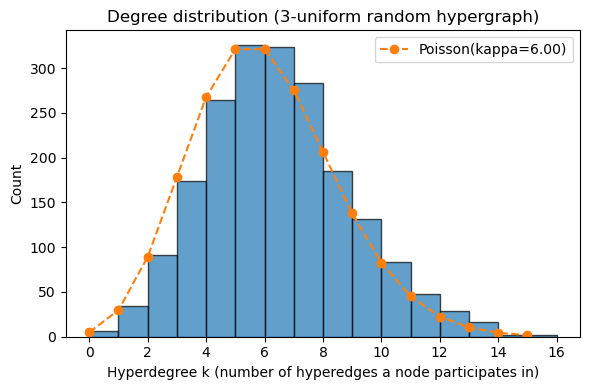

Example hyperedges: [(405, 1523, 1851), (59, 674, 877), (625, 1419, 1426), (728, 1265, 1742), (573, 911, 1759)]...


In [5]:
"""
Generate a random 3-uniform hypergraph H(n, m, 3) with no duplicate hyperedges.
- n:  节点数
- m:  超边数目
- kappa:  每个节点期望的平均（超）度
- d: 超边大小(此处固定为3)
- seed: random seed (None => random)
Returns:
- hyperedges: list of tuples (i,j,k) with i<j<k 超边三元组
- node_degrees: numpy array length n with hyperdegree counts 数组长度同节点数目n
Usage example:
    hyperedges, deg = generate_uniform_hypergraph(n=2000, kappa=6, seed=42)
"""
import random
import math
from itertools import combinations
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

# -包装函数，用于计算组合数 C(n,k)，
def comb(n, k):
    return math.comb(n, k)

def generate_uniform_hypergraph(n, kappa, d=3, seed=None, verbose=True, batch_size=1000):
    """
    Generate H(n, m, d) with m = round(n * kappa / d).

    使用不同d元组的随机抽样,拒绝重复.
    Use random sampling of distinct d-tuples, rejecting duplicates. 

    batch_size——批量采样大小(优化性能)
    - batch_size: attempt to create edges in batches to reduce Python overhead (helps when n large).
    """
    if seed is not None:
        random.seed(seed)      # 设置Python内置random模块的种子
        np.random.seed(seed)   # 设置NumPy随机数生成器的种子

    if d != 3:
        raise ValueError("This implementation targets d=3. For general d modify sampling accordingly.")

    m = int(round(n * kappa / d))
    # C(2000, 3) = 1,331,334,000
    max_possible = comb(n, d)
    if m > max_possible:
        #确保请求的超边数量不超过理论上可能的最大值
        raise ValueError(f"Requested m={m} exceeds total possible C(n,3)={max_possible}.")
    
    # 显示进度信息，便于调试和监控
    if verbose:
        print(f"Generating H(n={n}, m={m}, d={d}), expected average degree κ={kappa}")

    edges_set = set()      # store canonical tuples (i,j,k) with i<j<k
    nodes = np.arange(n)

    # Efficient-ish loop: sample in batches 高效循环：分批取样
    attempts = 0
    while len(edges_set) < m:
        '''
        # generate batch_size candidate hyperedges 
        # vectorized approach: sample 3 * batch_size indices and reshape to triples (with replacement within triple)
        # then enforce distinct nodes in each triple (resample invalid triples)
        # Simpler approach: for moderate sparsity, repeatedly sample until fill
        '''
        # 生成batch_size的候选超边
        # 高效的抽样方法：一次性抽样3倍的batch_size个索引，然后reshape成三元组(允许重复)
        # 然后在每个三元组中强制要求不重复的节点(重新采样无效的三元组)
        # 简单的方法：对于稀疏的情况，重复抽样直到填满

        batch = []
        # 分批次完成 4000条边 ÷ 1000条/批次（batch_size） = 4个批次
        for _ in range(batch_size):
            # 随机选3个不同节点
            tri = np.random.choice(nodes, size=3, replace=False)
            # 排序保证(i,j,k)且i<j<k
            tri.sort()
            batch.append(tuple(tri.tolist()))
        # insert unique new ones
        for tri in batch:
            if len(edges_set) >= m:
                break
            if tri not in edges_set:
                edges_set.add(tri)

        attempts += batch_size
        # Optional verbose progress 
        # 可选详细进度
        if verbose and (attempts // batch_size) % 50 == 0:
            print(f"  progress: {len(edges_set)}/{m} edges collected (attempts ~ {attempts})")

    # finalize list
    hyperedges = list(edges_set)
    # compute node degrees
    deg = np.zeros(n, dtype=int)
    for (i,j,k) in hyperedges:
        deg[i] += 1
        deg[j] += 1
        deg[k] += 1

    if verbose:
        # attempts = 4000 意味着尝试了4000次，成功了4000次
        print(f"Finished: collected {len(hyperedges)} edges after ~{attempts} candidate batches.")
        print(f"Actual average degree = {deg.mean():.4f} (target κ={kappa})")

    return hyperedges, deg

# ------------------------
# utilities: plot degree distribution and compare to Poisson
# ------------------------
def plot_degree_distribution(deg, kappa=None, bins=30, show_poisson=True):
    """
    Plot degree histogram and (optionally) overlay a Poisson distribution with mean kappa.
    """
    from scipy.stats import poisson
    n = len(deg)
    unique, counts = np.unique(deg, return_counts=True)
    plt.figure(figsize=(6,4))
    plt.hist(deg, bins=range(int(deg.max())+2), alpha=0.7, density=False, edgecolor='black')
    plt.xlabel("Hyperdegree k (number of hyperedges a node participates in)")
    plt.ylabel("Count")
    plt.title("Degree distribution (3-uniform random hypergraph)")
    if show_poisson:
        if kappa is None:
            kappa = deg.mean()
        xs = np.arange(0, deg.max()+1)
        pmf = poisson.pmf(xs, mu=kappa) * len(deg)  # scale to counts
        plt.plot(xs, pmf, marker='o', linestyle='--', label=f"Poisson(kappa={kappa:.2f})")
        plt.legend()
    plt.tight_layout()
    plt.show()

# Example usage:
if __name__ == "__main__":
    # parameters
    n = 2000
    kappa = 6
    hyperedges, deg = generate_uniform_hypergraph(n=n, kappa=kappa, seed=42, batch_size=1000)
    plot_degree_distribution(deg, kappa=kappa)
    print(f"Example hyperedges: {hyperedges[:5]}...")


In [6]:

print(f"Example hyperedges: {hyperedges[:5]}...")


Example hyperedges: [(405, 1523, 1851), (59, 674, 877), (625, 1419, 1426), (728, 1265, 1742), (573, 911, 1759)]...
